<center>

# ML: High Dimensional Viz - UMAP : 20th September 2023

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,5)
from matplotlib.pyplot import cm
import seaborn as sns
from matplotlib.colors import ListedColormap


dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 64)
(1797,)


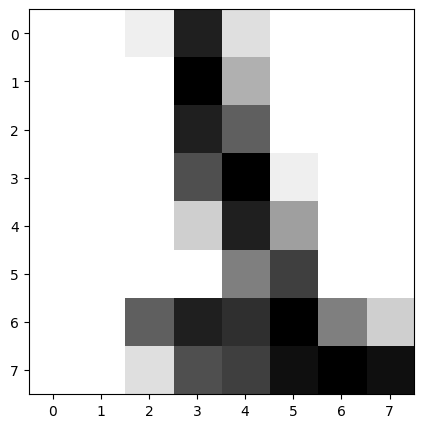

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.keys())
X = digits.data
Y = digits.target
print(X.shape)
print(Y.shape)
plt.gray()
plt.imshow(digits.images[1000], cmap=plt.cm.gray_r) #------> seems like number 1

In [ ]:
cmap = ListedColormap(sns.husl_palette(len(np.unique(Y))))

## PCA

#### **What can we interpret from this?**

- $7$ is represented by light bluish color, $8$ is represented by light purplish color and $9$ with slightly more dark pink color. You can see all these points are getting overlapped in the central region.

    This tells the similarity between three digits, as people have different handwritings and sometimes different digits often appears the same

- Whereas digits like $3$ and $4$  are difficult to get mixed and hence they are grouped around the left and right side of the plots respectively.

CPU times: user 167 ms, sys: 158 ms, total: 325 ms
Wall time: 438 ms


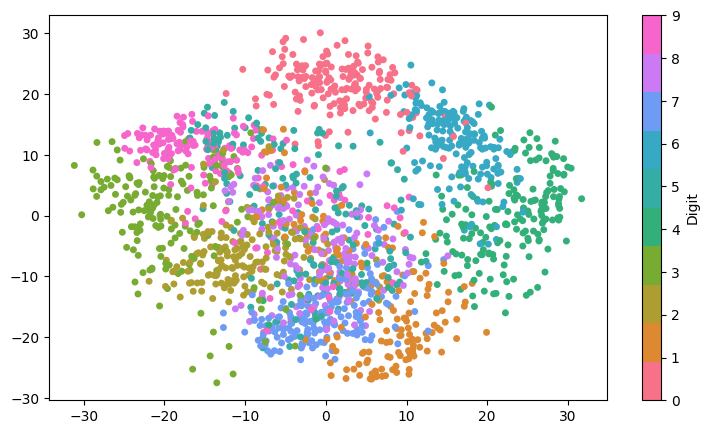

In [ ]:
%%time
from sklearn import decomposition

pca_2D = decomposition.PCA(n_components=2)
pca_2D.fit(X)
Z1 = pca_2D.transform(X)

fig, ax = plt.subplots()

im = ax.scatter(Z1[:,0], Z1[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')

## T-SNE

Unlike PCA, here if there were no labels($Y$), we can easily differentiate the different clusters

In [ ]:
!pip install openTSNE #https://opentsne.readthedocs.io/en/stable/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.1 MB/s eta 0:00:00


CPU times: user 24.6 s, sys: 160 ms, total: 24.8 s
Wall time: 25.5 s


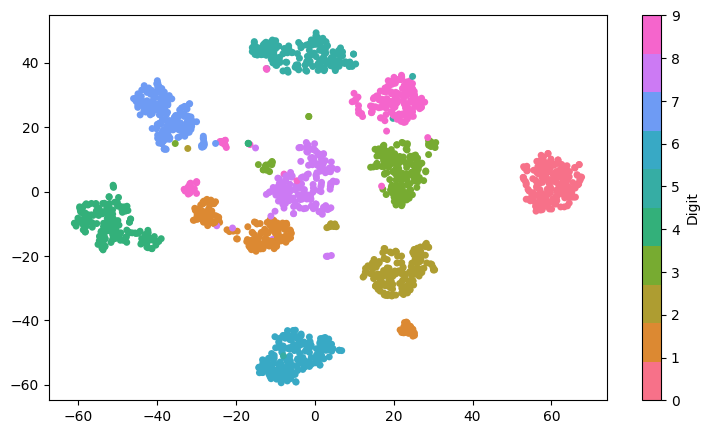

In [ ]:
%%time
from openTSNE import TSNE

Z2 = TSNE(n_jobs=-1, initialization='random', random_state=42, negative_gradient_method='bh').fit(X)

fig, ax = plt.subplots()
im = ax.scatter(Z2[:,0], Z2[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')

## UMAP

- faster than t-SNE for large data sets
- preserves global structures

<a href="https://pair-code.github.io/understanding-umap/"> UMAP blog </a>

In [ ]:
!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.8/90.8 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for umap-learn: filename=umap_learn-0.5.4-py3-none-any.whl size=86770 sha256=5a5cdf251d2449f23930536aec5a5776f9e234e6d2c31901d8a41f766199da1f
  Stored in directory: /root/.cache/pip/wheels/fb/66/29/199acf5784d0f7b8add6d466175ab45506c96e386ed5dd0633
  Created wheel for pynndescent: filename=pynndescent-0.5.10-py3-none-any.whl size=55615 sha256=384346f20932da0e6fe67874b3a9d1c2f6f5b652dd72951d5e637109f85616a6
  Stored in directory: /root/.cache/pip/wheels/4a/38/5d/f60a40a66a9512b7e5e83517ebc2d1b42d857be97d135f1096
Successfully built umap-learn pynndescent


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


CPU times: user 38.5 s, sys: 901 ms, total: 39.4 s
Wall time: 55.3 s


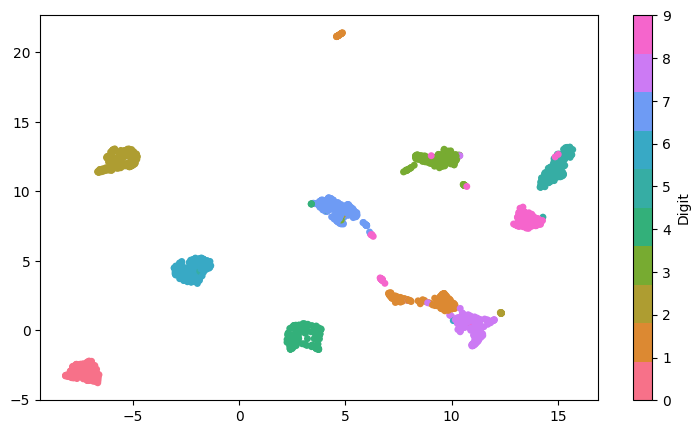

In [ ]:
%%time
from umap import UMAP

Z3 = UMAP(init='random', random_state=42).fit_transform(X)

fig, ax = plt.subplots()
im = ax.scatter(Z3[:,0], Z3[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')